BẮT ĐẦU QUY TRÌNH TRỰC QUAN HÓA DỮ LIỆU VÀ MÔ HÌNH (DATA VISUALIZATION)
Tải mô hình và dữ liệu thành công! Đang sinh biểu đồ...


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16288\3544492934.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x='Importance', y='Feature', ax=ax, palette='viridis')


Đã lưu Biểu đồ 1: 01_feature_importance.png


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_16288\3544492934.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ablation, x='R2 Score', y='Model', ax=ax, palette='coolwarm')


Đã lưu Biểu đồ 2: 02_ablation_study.png
Đã lưu Biểu đồ 3: 03_scatter_predict.png
Đã lưu Biểu đồ 4: 04_residual_dist.png
Đã lưu Biểu đồ 5: 05_simulation_trend.png

HOÀN TẤT! Toàn bộ 5 biểu đồ đã được lưu trong thư mục hiện tại.


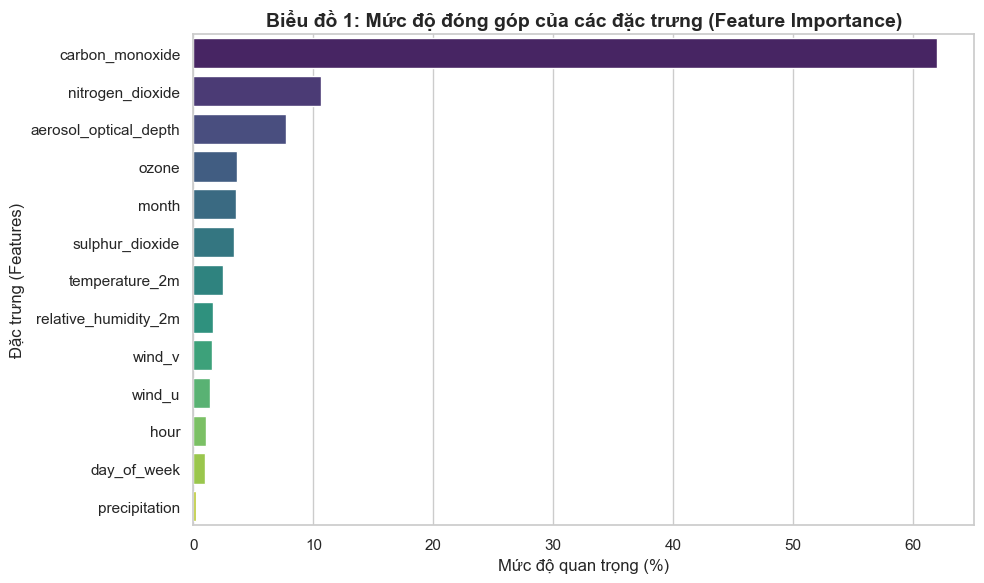

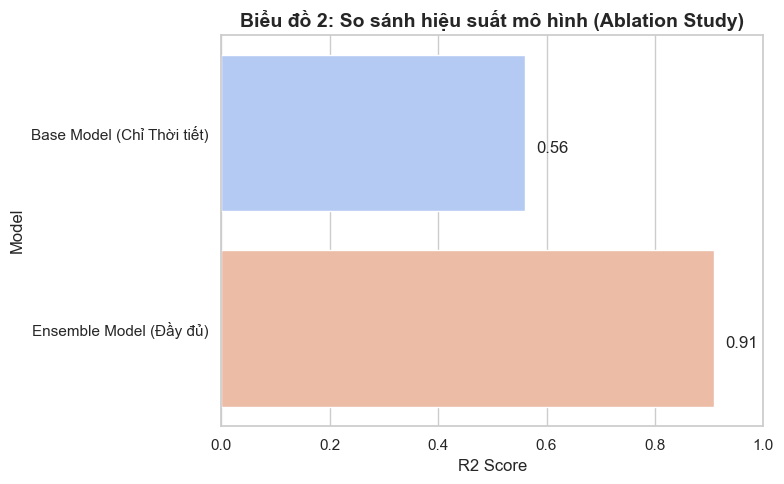

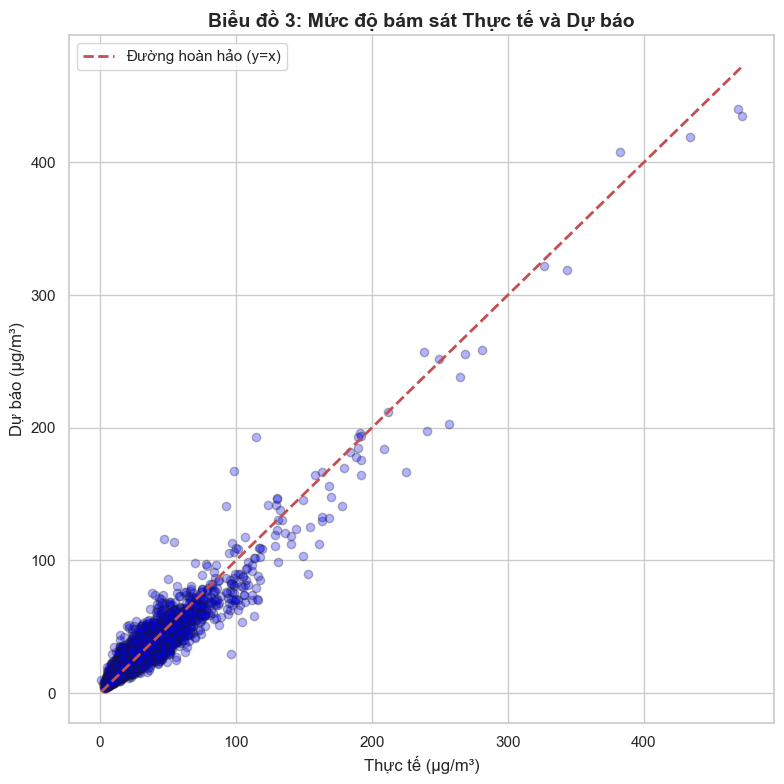

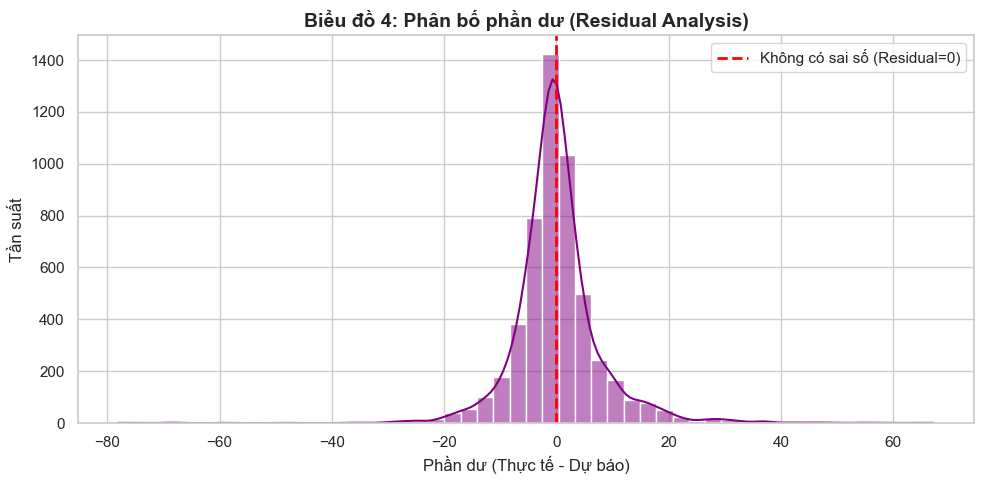

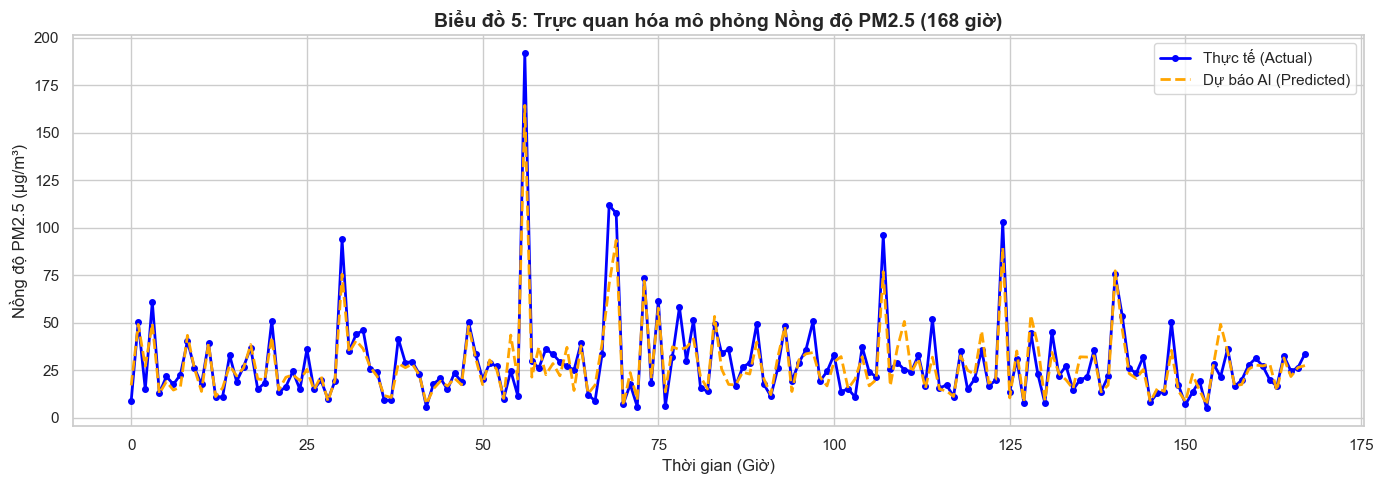

In [2]:
# 1. IMPORTS
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# 2. CONFIGURATIONS
CLEAN_FILE_PATH = 'data_dongmai_clean.csv'
MODEL_PATH = 'ensemble_model_pm25.pkl'
TARGET_COLUMN = 'pm2_5'

WEATHER_FEATURES = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 'wind_u', 'wind_v', 'hour', 'day_of_week', 'month']

# Định dạng chung cho biểu đồ
sns.set_theme(style="whitegrid")

# 3. CORE FUNCTIONS FOR VISUALIZATION

def plot_feature_importance(model, feature_names):
    """Biểu đồ 1: Mức độ quan trọng của biến"""
    rf_model = model.named_estimators_['rf']
    df_imp = pd.DataFrame({'Feature': feature_names, 'Importance': rf_model.feature_importances_ * 100})
    
    # Bắt buộc sắp xếp giảm dần cho Bar Chart
    df_imp = df_imp.sort_values(by='Importance', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(data=df_imp, x='Importance', y='Feature', ax=ax, palette='viridis')
    ax.set_title("Biểu đồ 1: Mức độ đóng góp của các đặc trưng (Feature Importance)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Mức độ quan trọng (%)")
    ax.set_ylabel("Đặc trưng (Features)")
    
    # Lưu biểu đồ, dùng bbox_inches='tight' để nhãn không bị cắt xén
    plt.savefig('01_feature_importance.png', bbox_inches='tight')
    print("Đã lưu Biểu đồ 1: 01_feature_importance.png")

def plot_ablation_study(X_train, X_test, y_train, y_test, full_y_pred):
    """Biểu đồ 2: Báo cáo Kiểm thử cô lập (Ablation Study)"""
    # Huấn luyện nhanh mô hình Base (Chỉ dùng thời tiết)
    X_train_weather = X_train[WEATHER_FEATURES]
    X_test_weather = X_test[WEATHER_FEATURES]
    
    rf_base = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
    rf_base.fit(X_train_weather, y_train)
    base_pred = rf_base.predict(X_test_weather)
    
    # Tính điểm R2
    r2_base = r2_score(y_test, base_pred)
    r2_full = r2_score(y_test, full_y_pred)
    
    # Chuẩn bị dữ liệu vẽ, sắp xếp giá trị tăng dần
    df_ablation = pd.DataFrame({
        'Model': ['Base Model (Chỉ Thời tiết)', 'Ensemble Model (Đầy đủ)'],
        'R2 Score': [r2_base, r2_full]
    })
    df_ablation = df_ablation.sort_values(by='R2 Score', ascending=True)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=df_ablation, x='R2 Score', y='Model', ax=ax, palette='coolwarm')
    ax.set_title("Biểu đồ 2: So sánh hiệu suất mô hình (Ablation Study)", fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.0)
    
    # Ghi chú giá trị R2 lên thanh bar
    for p in ax.patches:
        ax.annotate(f"{p.get_width():.2f}", (p.get_width() + 0.02, p.get_y() + 0.5))
        
    plt.savefig('02_ablation_study.png', bbox_inches='tight')
    print("Đã lưu Biểu đồ 2: 02_ablation_study.png")

def plot_scatter_predictions(y_true, y_pred):
    """Biểu đồ 3: Phân tán Thực tế vs Dự báo"""
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(y_true, y_pred, alpha=0.3, color='blue', edgecolor='k')
    
    # Vẽ đường chéo y = x (Dự báo hoàn hảo)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Đường hoàn hảo (y=x)')
    
    ax.set_title("Biểu đồ 3: Mức độ bám sát Thực tế và Dự báo", fontsize=14, fontweight='bold')
    ax.set_xlabel("Thực tế (µg/m³)")
    ax.set_ylabel("Dự báo (µg/m³)")
    ax.legend()
    
    plt.savefig('03_scatter_predict.png', bbox_inches='tight')
    print("Đã lưu Biểu đồ 3: 03_scatter_predict.png")

def plot_residual_distribution(y_true, y_pred):
    """Biểu đồ 4: Phân bố phần dư (Residuals)"""
    residuals = y_true.values - y_pred
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(residuals, kde=True, ax=ax, color='purple', bins=50)
    ax.axvline(x=0, color='red', linestyle='--', lw=2, label='Không có sai số (Residual=0)')
    
    ax.set_title("Biểu đồ 4: Phân bố phần dư (Residual Analysis)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Phần dư (Thực tế - Dự báo)")
    ax.set_ylabel("Tần suất")
    ax.legend()
    
    plt.savefig('04_residual_dist.png', bbox_inches='tight')
    print("Đã lưu Biểu đồ 4: 04_residual_dist.png")

def plot_time_series_simulation(y_true, y_pred):
    """Biểu đồ 5: Mô phỏng chuỗi thời gian (Trích xuất 168 giờ - 1 tuần)"""
    # Lấy ngẫu nhiên 168 điểm (1 tuần)
    hours = 168
    y_true_subset = y_true.values[:hours]
    y_pred_subset = y_pred[:hours]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(y_true_subset, label='Thực tế (Actual)', color='blue', lw=2, marker='o', markersize=4)
    ax.plot(y_pred_subset, label='Dự báo AI (Predicted)', color='orange', lw=2, linestyle='--')
    
    ax.set_title("Biểu đồ 5: Trực quan hóa mô phỏng Nồng độ PM2.5 (168 giờ)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Thời gian (Giờ)")
    ax.set_ylabel("Nồng độ PM2.5 (µg/m³)")
    ax.legend()
    
    plt.savefig('05_simulation_trend.png', bbox_inches='tight')
    print("Đã lưu Biểu đồ 5: 05_simulation_trend.png")

# 4. MAIN EXECUTION
if __name__ == "__main__":
    print("BẮT ĐẦU QUY TRÌNH TRỰC QUAN HÓA DỮ LIỆU VÀ MÔ HÌNH (DATA VISUALIZATION)")
    
    try:
        # Tải dữ liệu và mô hình
        df = pd.read_csv(CLEAN_FILE_PATH)
        X = df.drop(columns=[TARGET_COLUMN])
        y = df[TARGET_COLUMN]
        
        # Chia dữ liệu giống hệ file 03 để đảm bảo tính nhất quán (random_state=42)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
        
        model = joblib.load(MODEL_PATH)
        print("Tải mô hình và dữ liệu thành công! Đang sinh biểu đồ...")
        
        # Chạy dự báo
        y_pred = model.predict(X_test)
        
        # Sinh 5 biểu đồ
        plot_feature_importance(model, X.columns.tolist())
        plot_ablation_study(X_train, X_test, y_train, y_test, y_pred)
        plot_scatter_predictions(y_test, y_pred)
        plot_residual_distribution(y_test, y_pred)
        plot_time_series_simulation(y_test, y_pred)
        
        print("\nHOÀN TẤT! Toàn bộ 5 biểu đồ đã được lưu trong thư mục hiện tại.")
        
    except FileNotFoundError as e:
        print(f"Lỗi không tìm thấy file: {e}. Vui lòng đảm bảo đã chạy các file tiền xử lý và huấn luyện trước đó.")